In [8]:
import pandas as pd
import nibabel as nib
import numpy as np
import cv2
import matplotlib.pyplot as plt
import random
from pathlib import Path
import torch

In [14]:
dataset = pd.read_csv('../data/processed_dataset/GLCM/2d_1_slice_texture_radiomics_dataset_clean.csv')

Sample Index: 1546 | Original ROI: (451, 333, 83)


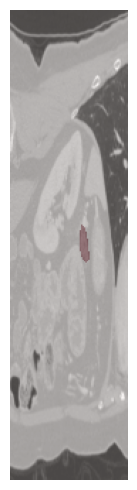

In [ ]:
# original image
idx = 1546
ct_data = nib.load(dataset["ct_image_path"].iloc[idx]).get_fdata(dtype=np.float32)
mask_data = nib.load(dataset["mask_path"].iloc[idx]).get_fdata(dtype=np.float32)
mask_data = (mask_data > 0).astype(np.float32)
z_idx = int(dataset["z_middle_global"].iloc[idx])
print(f"Sample Index: {idx} | {mask_data.shape}")
plt.figure(figsize=(12, 5))
plt.imshow(ct_data[z_idx, :, :], cmap='gray')
plt.imshow(mask_data[z_idx, :, :], cmap='Reds', alpha=0.3)
plt.axis('off')
plt.tight_layout()
plt.show()

In [10]:
def pad_volume(volume, target_shape):
    c, d, h, w = volume.shape
    th, tw = target_shape
    if h > th:
        start_h = (h - th) // 2
        volume = volume[:, :, start_h:start_h + th, :]
        h = th
    if w > tw:
        start_w = (w - tw) // 2
        volume = volume[:, :, :, start_w:start_w + tw]
        w = tw
    pad_h, pad_w = max(th - h, 0), max(tw - w, 0)
    padded = np.pad(
        volume,
        ((0,0),(0,0),(pad_h//2, pad_h - pad_h//2),(pad_w//2, pad_w - pad_w//2)),
        mode="constant", constant_values=0
    )
    return padded

def process_one(args):
    idx, row, cache_dir, target_shape = args
    cache_dir = Path(cache_dir)
    out_path  = cache_dir / f"sample_{idx}.pt"

    if out_path.exists():
        return idx, "skipped"

    try:
        ct_data   = nib.load(row["ct_image_path"]).get_fdata(dtype=np.float32)
        mask_data = nib.load(row["mask_path"]).get_fdata(dtype=np.float32)
        mask_data = (mask_data > 0).astype(np.float32)

        if ct_data.shape != mask_data.shape:
            return idx, f"shape mismatch {ct_data.shape} vs {mask_data.shape}"

        z_middle_global = int(row["z_middle_global"])

        if z_middle_global < 0 or z_middle_global >= ct_data.shape[0]:
            return idx, f"z_middle_global={z_middle_global} out of bounds for shape {ct_data.shape}"

        # Compute 3D bounding box from full mask — same crop as radiomics_dataset_generation.py
        coords = np.where(mask_data > 0)
        if coords[0].size == 0:
            return idx, "empty mask"

        margin = 10
        ymin = max(coords[1].min() - margin, 0)
        ymax = min(coords[1].max() + margin, mask_data.shape[1])
        xmin = max(coords[2].min() - margin, 0)
        xmax = min(coords[2].max() + margin, mask_data.shape[2])

        # Extract the exact same 2D crop MIRP received during feature extraction
        ct_slice   = ct_data[z_middle_global, ymin:ymax, xmin:xmax]
        mask_slice = mask_data[z_middle_global, ymin:ymax, xmin:xmax]

        if np.sum(mask_slice) == 0:
            return idx, "empty slice"

        # Add channel dimension → (1, H, W)
        ct_slice   = ct_slice[np.newaxis, :, :]
        mask_slice = mask_slice[np.newaxis, :, :]

        # Stack → (2, H, W)
        x = np.concatenate([ct_slice, mask_slice], axis=0)

        # Pad or crop to target shape using pad_volume
        x = np.expand_dims(x, axis=1)   # (2, 1, H, W)
        x = pad_volume(x, target_shape)  # (2, 1, 128, 128)
        x = x[:, 0, :, :]               # (2, 128, 128)

        torch.save(torch.tensor(x, dtype=torch.float32), out_path)
        return idx, "ok"

    except Exception as e:
        return idx, f"error: {e}"

In [27]:
def show_final_overlay(row, target_shape=(128, 128)):
    # 1. Reproduce processing logic
    ct_data = nib.load(row["ct_image_path"]).get_fdata(dtype=np.float32)
    mask_data = nib.load(row["mask_path"]).get_fdata(dtype=np.float32)
    mask_data = (mask_data > 0).astype(np.float32)
    
    z_idx = int(row["z_middle_global"])
    coords = np.where(mask_data > 0)
    
    # Crop logic
    margin = 10
    ymin, ymax = max(coords[1].min()-margin, 0), min(coords[1].max()+margin, mask_data.shape[1])
    xmin, xmax = max(coords[2].min()-margin, 0), min(coords[2].max()+margin, mask_data.shape[2])
    
    ct_slice = ct_data[z_idx, ymin:ymax, xmin:xmax][np.newaxis, np.newaxis, :, :]
    mask_slice = mask_data[z_idx, ymin:ymax, xmin:xmax][np.newaxis, np.newaxis, :, :]
    
    # Concatenate and Pad
    x = np.concatenate([ct_slice, mask_slice], axis=0) # (2, 1, H, W)
    x = pad_volume(x, target_shape)                   # (2, 1, 128, 128)
    final_result = x[:, 0, :, :]                      # (2, 128, 128)

    # 2. Plotting
    plt.figure(figsize=(6, 6))
    
    # Display CT Background
    plt.imshow(final_result[0], cmap='gray')
    
    # Create a masked array to make 0-values in mask transparent
    mask_display = np.ma.masked_where(final_result[1] == 0, final_result[1])
    
    # Overlay Mask (using 'autumn' or 'jet' for high contrast)
    plt.imshow(mask_display, cmap='autumn', alpha=0.4) 
    
    plt.title(f"Final Overlay (Idx: {row.name}) - Shape: {target_shape}")
    plt.axis('off')
    plt.show()

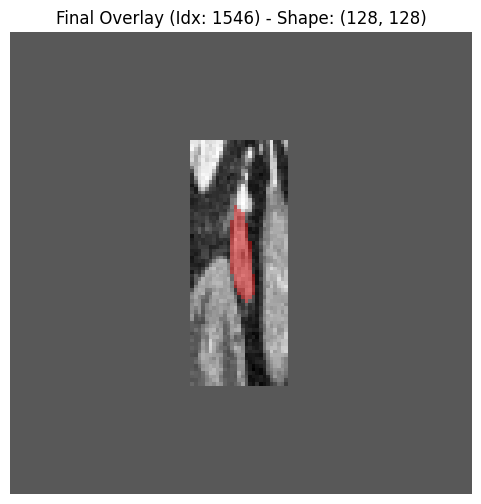

In [28]:
show_final_overlay(dataset.iloc[idx], target_shape=(128, 128))

## cropping and scaling

In [ ]:
target_shape = (224, 224)
ct_data = nib.load(dataset["ct_image_path"].iloc[idx]).get_fdata(dtype=np.float32)
mask_data = nib.load(dataset["mask_path"].iloc[idx]).get_fdata(dtype=np.float32)
mask_data = (mask_data > 0).astype(np.float32)
z_idx = int(dataset["z_middle_global"].iloc[idx])
coords = np.where(mask_data > 0)
margin = 10
ymin, ymax = max(coords[1].min()-margin, 0), min(coords[1].max()+margin, ct_data.shape[1])
xmin, xmax = max(coords[2].min()-margin, 0), min(coords[2].max()+margin, ct_data.shape[2])
roi_ct = ct_data[z_idx, ymin:ymax, xmin:xmax]
xmin, xmax = max(coords[2].min()-margin, 0), min(coords[2].max()+margin, ct_data.shape[2])
scaled_ct = cv2.resize(roi_ct, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_LINEAR)
scaled_mask = cv2.resize(roi_mask, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_NEAREST)
plt.imshow(scaled_ct, cmap='gray')
plt.imshow(scaled_mask, cmap='Reds', alpha=0.3)
plt.title(f"Scaled to {target_shape}")

## With cropping

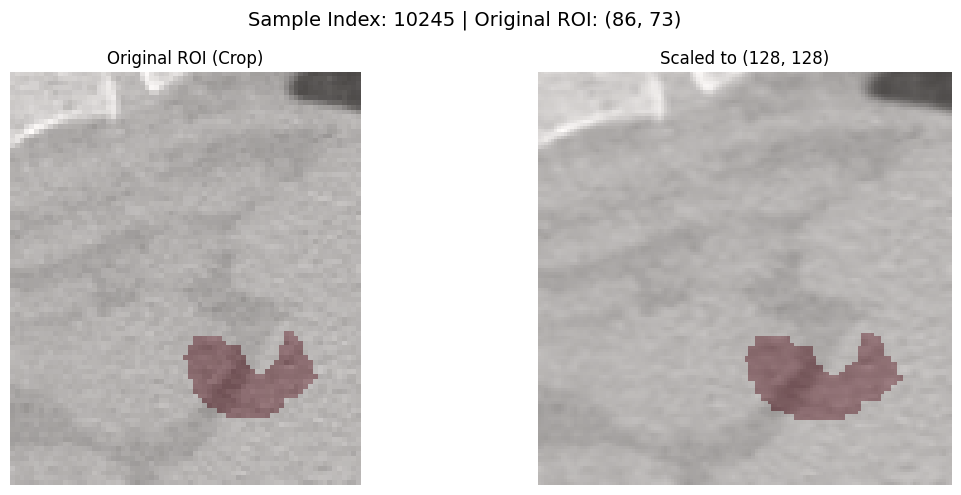

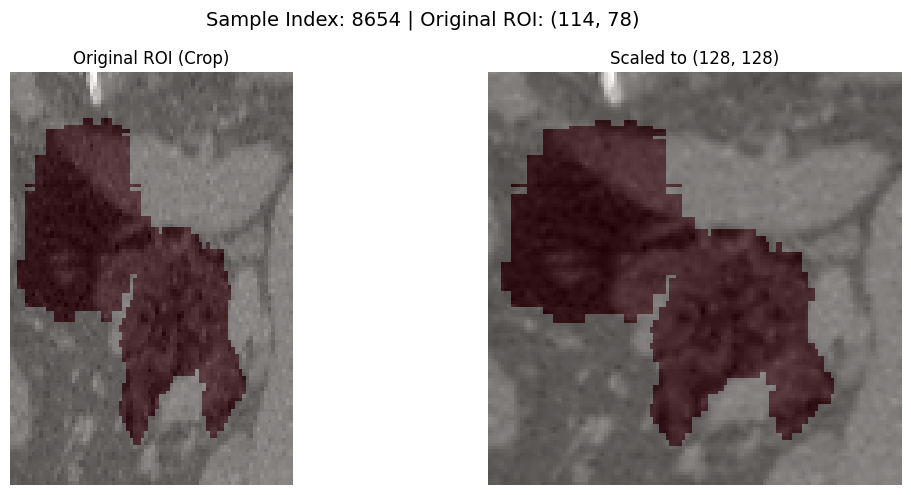

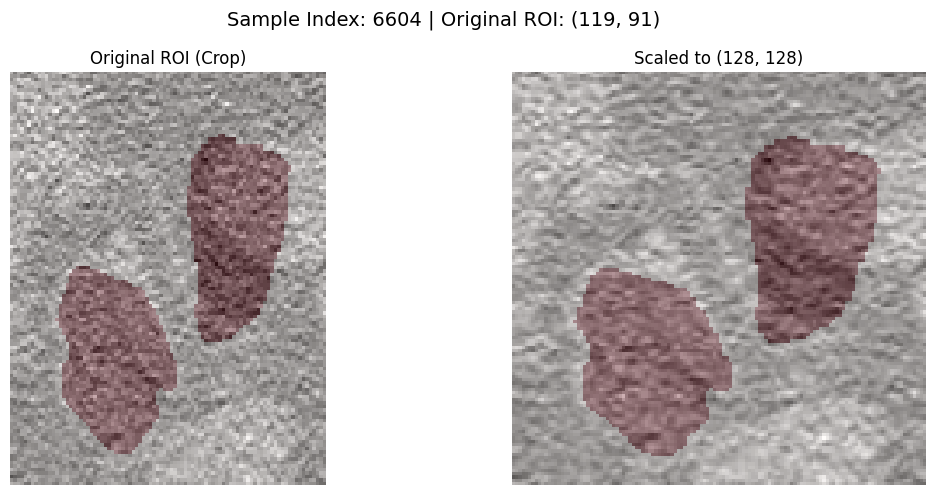

In [3]:
def test_scaling(csv_path, target_shape=(128, 128), num_samples=3):
    df = pd.read_csv(csv_path)
    # Pick random indices to get a variety of tumor sizes
    sample_indices = random.sample(range(len(df)), num_samples)
    
    for idx in sample_indices:
        row = df.iloc[idx]
        
        # 1. Load original data
        ct_data = nib.load(row["ct_image_path"]).get_fdata(dtype=np.float32)
        mask_data = nib.load(row["mask_path"]).get_fdata(dtype=np.float32)
        mask_data = (mask_data > 0).astype(np.float32)
        z_idx = int(row["z_middle_global"])
        
        # 2. Extract the original ROI (the "Crop")
        coords = np.where(mask_data > 0)
        margin = 10
        ymin, ymax = max(coords[1].min()-margin, 0), min(coords[1].max()+margin, ct_data.shape[1])
        xmin, xmax = max(coords[2].min()-margin, 0), min(coords[2].max()+margin, ct_data.shape[2])
        
        roi_ct = ct_data[z_idx, ymin:ymax, xmin:xmax]
        roi_mask = mask_data[z_idx, ymin:ymax, xmin:xmax]
        
        # 3. Apply Scaling (Resizing)
        scaled_ct = cv2.resize(roi_ct, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_LINEAR)
        scaled_mask = cv2.resize(roi_mask, (target_shape[1], target_shape[0]), interpolation=cv2.INTER_NEAREST)
        
        # 4. Visualization
        plt.figure(figsize=(12, 5))
        plt.suptitle(f"Sample Index: {idx} | Original ROI: {roi_ct.shape}", fontsize=14)
        
        # Left: Original ROI (Natural Aspect Ratio)
        plt.subplot(1, 2, 1)
        plt.imshow(roi_ct, cmap='gray')
        plt.imshow(roi_mask, cmap='Reds', alpha=0.3)
        plt.title("Original ROI (Crop)")
        plt.axis('off')
        
        # Right: Scaled Result (Forced to 128x128)
        plt.subplot(1, 2, 2)
        plt.imshow(scaled_ct, cmap='gray')
        plt.imshow(scaled_mask, cmap='Reds', alpha=0.3)
        plt.title(f"Scaled to {target_shape}")
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()

# Run the test
test_scaling("../data/processed_dataset/GLCM/2d_1_slice_texture_radiomics_dataset_clean.csv")